In [2]:
import os
import glob
import warnings
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mne

from scipy.signal import welch
from scipy.stats import skew, kurtosis

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import roc_curve, roc_auc_score

from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

# EEG configuration
DATASET_ROOT = r"C:\Users\Sanjeev\OneDrive\Desktop\Brain ID\EEG\ds004148"

CHANNELS = ["Fp1", "Fp2", "Fz"]

EXPECTED_FS = 500

WINDOW_SECONDS = 4
WINDOW_SAMPLES = EXPECTED_FS * WINDOW_SECONDS

STEP_SECONDS = 4
STEP_SAMPLES = EXPECTED_FS * STEP_SECONDS

LOWCUT = 0.3
HIGHCUT = 45.0

ARTIFACT_PTP_UV = 100.0
MIN_CHANNEL_STD_UV = 0.1

BANDS = {
    "delta": (1, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta": (13, 30),
    "gamma": (30, 45)
}

print("Imports successful.")
print("MNE version:", mne.__version__)

Imports successful.
MNE version: 1.13.2


In [3]:
vhdr_files = sorted(
    glob.glob(
        os.path.join(
            DATASET_ROOT,
            "sub-*",
            "ses-*",
            "eeg",
            "*.vhdr"
        )
    )
)

print("Total EEG recordings found:", len(vhdr_files))

print("\nFirst 10 files:")
for f in vhdr_files[:10]:
    print(f)

Total EEG recordings found: 180

First 10 files:
C:\Users\Sanjeev\OneDrive\Desktop\Brain ID\EEG\ds004148\sub-01\ses-session1\eeg\sub-01_ses-session1_task-memory_eeg.vhdr
C:\Users\Sanjeev\OneDrive\Desktop\Brain ID\EEG\ds004148\sub-01\ses-session2\eeg\sub-01_ses-session2_task-memory_eeg.vhdr
C:\Users\Sanjeev\OneDrive\Desktop\Brain ID\EEG\ds004148\sub-01\ses-session3\eeg\sub-01_ses-session3_task-memory_eeg.vhdr
C:\Users\Sanjeev\OneDrive\Desktop\Brain ID\EEG\ds004148\sub-02\ses-session1\eeg\sub-02_ses-session1_task-memory_eeg.vhdr
C:\Users\Sanjeev\OneDrive\Desktop\Brain ID\EEG\ds004148\sub-02\ses-session2\eeg\sub-02_ses-session2_task-memory_eeg.vhdr
C:\Users\Sanjeev\OneDrive\Desktop\Brain ID\EEG\ds004148\sub-02\ses-session3\eeg\sub-02_ses-session3_task-memory_eeg.vhdr
C:\Users\Sanjeev\OneDrive\Desktop\Brain ID\EEG\ds004148\sub-03\ses-session1\eeg\sub-03_ses-session1_task-memory_eeg.vhdr
C:\Users\Sanjeev\OneDrive\Desktop\Brain ID\EEG\ds004148\sub-03\ses-session2\eeg\sub-03_ses-session2_task

In [4]:
records = []

for vhdr in vhdr_files:

    parts = os.path.normpath(vhdr).split(os.sep)

    subject = next(
        p for p in parts
        if p.startswith("sub-")
    )

    session = next(
        p for p in parts
        if p.startswith("ses-")
    )

    records.append({
        "subject": subject,
        "session": session,
        "vhdr": vhdr
    })

records_df = pd.DataFrame(records)

print(records_df.head())

print("\nSubjects:")
print(records_df["subject"].nunique())

print("\nSessions:")
print(records_df["session"].value_counts())

print("\nRecordings:")
print(len(records_df))

  subject       session                                               vhdr
0  sub-01  ses-session1  C:\Users\Sanjeev\OneDrive\Desktop\Brain ID\EEG...
1  sub-01  ses-session2  C:\Users\Sanjeev\OneDrive\Desktop\Brain ID\EEG...
2  sub-01  ses-session3  C:\Users\Sanjeev\OneDrive\Desktop\Brain ID\EEG...
3  sub-02  ses-session1  C:\Users\Sanjeev\OneDrive\Desktop\Brain ID\EEG...
4  sub-02  ses-session2  C:\Users\Sanjeev\OneDrive\Desktop\Brain ID\EEG...

Subjects:
60

Sessions:
session
ses-session1    60
ses-session2    60
ses-session3    60
Name: count, dtype: int64

Recordings:
180


In [5]:
test_file = vhdr_files[0]

print("Testing:")
print(test_file)

raw = mne.io.read_raw_brainvision(
    test_file,
    preload=True,
    verbose=False
)

print("\nSampling frequency:")
print(raw.info["sfreq"])

print("\nNumber of channels:")
print(len(raw.ch_names))

print("\nFirst channels:")
print(raw.ch_names[:20])

Testing:
C:\Users\Sanjeev\OneDrive\Desktop\Brain ID\EEG\ds004148\sub-01\ses-session1\eeg\sub-01_ses-session1_task-memory_eeg.vhdr

Sampling frequency:
500.0

Number of channels:
61

First channels:
['Fp1', 'AF3', 'AF7', 'Fz', 'F1', 'F3', 'F5', 'F7', 'FC1', 'FC3', 'FC5', 'FT7', 'Cz', 'C1', 'C3', 'C5', 'T7', 'CP1', 'CP3', 'CP5']


In [6]:
missing = [
    ch for ch in CHANNELS
    if ch not in raw.ch_names
]

if missing:
    raise ValueError(
        f"Missing channels: {missing}"
    )

raw_3ch = raw.copy().pick(CHANNELS)

print(raw_3ch)
print("\nSelected channels:")
print(raw_3ch.ch_names)

print("\nSampling rate:")
print(raw_3ch.info["sfreq"])

<RawBrainVision | sub-01_ses-session1_task-memory_eeg.eeg, 3 x 150000 (300.0 s), ~3.4 MiB, data loaded>

Selected channels:
['Fp1', 'Fp2', 'Fz']

Sampling rate:
500.0


In [7]:
def preprocess_recording(vhdr_path):

    raw = mne.io.read_raw_brainvision(
        vhdr_path,
        preload=True,
        verbose=False
    )

    # ------------------------------------------------
    # Check sampling frequency
    # ------------------------------------------------

    fs = raw.info["sfreq"]

    if abs(fs - EXPECTED_FS) > 1e-6:
        raise ValueError(
            f"Expected {EXPECTED_FS} Hz but found {fs} Hz:\n"
            f"{vhdr_path}"
        )

    # ------------------------------------------------
    # Select channels
    # ------------------------------------------------

    missing = [
        ch for ch in CHANNELS
        if ch not in raw.ch_names
    ]

    if missing:
        raise ValueError(
            f"Missing channels {missing} in {vhdr_path}"
        )

    raw.pick(CHANNELS)

    # ------------------------------------------------
    # Bandpass filter
    # ------------------------------------------------

    raw.filter(
        l_freq=LOWCUT,
        h_freq=HIGHCUT,
        method="fir",
        phase="zero",
        verbose=False
    )

    # ------------------------------------------------
    # Get data
    # ------------------------------------------------

    data = raw.get_data()

    # Convert V → µV
    data_uv = data * 1e6

    # ------------------------------------------------
    # Windowing
    # ------------------------------------------------

    n_samples = data_uv.shape[1]

    windows = []
    rejected = 0

    for start in range(
        0,
        n_samples - WINDOW_SAMPLES + 1,
        STEP_SAMPLES
    ):

        end = start + WINDOW_SAMPLES

        window = data_uv[:, start:end]

        # --------------------------------------------
        # NaN / Inf
        # --------------------------------------------

        if not np.isfinite(window).all():
            rejected += 1
            continue

        # --------------------------------------------
        # Frontal artifact rejection
        # --------------------------------------------

        fp1_ptp = np.ptp(window[0])
        fp2_ptp = np.ptp(window[1])

        if (
            fp1_ptp > ARTIFACT_PTP_UV
            or
            fp2_ptp > ARTIFACT_PTP_UV
        ):
            rejected += 1
            continue

        # --------------------------------------------
        # Flatline rejection
        # --------------------------------------------

        channel_std = np.std(
            window,
            axis=1
        )

        if np.any(
            channel_std < MIN_CHANNEL_STD_UV
        ):
            rejected += 1
            continue

        windows.append(window)

    if len(windows) == 0:
        return np.empty(
            (0, 3, WINDOW_SAMPLES),
            dtype=np.float32
        ), rejected

    windows = np.asarray(
        windows,
        dtype=np.float32
    )

    return windows, rejected

In [8]:
windows, rejected = preprocess_recording(
    vhdr_files[0]
)

print("Windows:", windows.shape)
print("Rejected:", rejected)

if len(windows) > 0:

    print("\nWindow shape:")
    print(windows[0].shape)

    print("\nExpected:")
    print("(3, 2000)")

Windows: (69, 3, 2000)
Rejected: 6

Window shape:
(3, 2000)

Expected:
(3, 2000)


In [9]:
all_windows = []
metadata = []

total_rejected = 0

start_time = time.time()

for _, row in tqdm(
    records_df.iterrows(),
    total=len(records_df),
    desc="Preprocessing EEG"
):

    subject = row["subject"]
    session = row["session"]
    vhdr = row["vhdr"]

    try:

        windows, rejected = preprocess_recording(
            vhdr
        )

    except Exception as e:

        print("\nERROR:")
        print(vhdr)
        print(e)
        continue

    total_rejected += rejected

    for i, window in enumerate(windows):

        all_windows.append(window)

        metadata.append({
            "subject": subject,
            "session": session,
            "window": i
        })

X_raw = np.asarray(
    all_windows,
    dtype=np.float32
)

metadata_df = pd.DataFrame(
    metadata
)

print("\n==============================")
print("PREPROCESSING COMPLETE")
print("==============================")

print("X shape:", X_raw.shape)

print(
    "Total accepted windows:",
    len(X_raw)
)

print(
    "Total rejected windows:",
    total_rejected
)

print(
    "Time:",
    round((time.time() - start_time) / 60, 2),
    "minutes"
)

Preprocessing EEG:   0%|          | 0/180 [00:00<?, ?it/s]


PREPROCESSING COMPLETE
X shape: (8735, 3, 2000)
Total accepted windows: 8735
Total rejected windows: 4761
Time: 0.82 minutes


In [10]:
PROCESSED_DIR = os.path.join(
    DATASET_ROOT,
    "processed"
)

os.makedirs(
    PROCESSED_DIR,
    exist_ok=True
)

np.save(
    os.path.join(
        PROCESSED_DIR,
        "X_raw.npy"
    ),
    X_raw
)

metadata_df.to_csv(
    os.path.join(
        PROCESSED_DIR,
        "metadata.csv"
    ),
    index=False
)

print("Saved preprocessing results.")

Saved preprocessing results.


In [11]:
def hjorth_parameters(signal):

    activity = np.var(signal)

    diff1 = np.diff(signal)
    diff2 = np.diff(diff1)

    var_diff1 = np.var(diff1)
    var_diff2 = np.var(diff2)

    if activity <= 1e-12:
        mobility = 0.0
    else:
        mobility = np.sqrt(
            var_diff1 / activity
        )

    if var_diff1 <= 1e-12:
        complexity = 0.0
    else:
        mobility_diff = np.sqrt(
            var_diff2 / var_diff1
        )

        complexity = (
            mobility_diff / mobility
            if mobility > 1e-12
            else 0.0
        )

    return activity, mobility, complexity

In [12]:
def extract_features(window, fs=500):

    features = []
    names = []

    for ch_idx, ch_name in enumerate(CHANNELS):

        signal = window[ch_idx]

        # ------------------------------------------
        # Time-domain
        # ------------------------------------------

        mean_val = np.mean(signal)
        std_val = np.std(signal)
        rms_val = np.sqrt(
            np.mean(signal ** 2)
        )

        skew_val = skew(signal)
        kurt_val = kurtosis(signal)

        activity, mobility, complexity = (
            hjorth_parameters(signal)
        )

        time_features = {
            "mean": mean_val,
            "std": std_val,
            "rms": rms_val,
            "skew": skew_val,
            "kurtosis": kurt_val,
            "hjorth_activity": activity,
            "hjorth_mobility": mobility,
            "hjorth_complexity": complexity
        }

        for name, value in time_features.items():

            names.append(
                f"{ch_name}_{name}"
            )

            features.append(value)

        # ------------------------------------------
        # Welch PSD
        # ------------------------------------------

        freqs, psd = welch(
            signal,
            fs=fs,
            nperseg=min(
                512,
                len(signal)
            ),
            noverlap=None
        )

        # 1–45 Hz
        valid = (
            (freqs >= 1)
            &
            (freqs <= 45)
        )

        freqs_valid = freqs[valid]
        psd_valid = psd[valid]

        total_power = np.trapezoid(
            psd_valid,
            freqs_valid
        )

        # ------------------------------------------
        # Band powers
        # ------------------------------------------

        band_powers = {}

        for band_name, (low, high) in BANDS.items():

            mask = (
                (freqs >= low)
                &
                (freqs < high)
            )

            if np.any(mask):

                power = np.trapezoid(
                    psd[mask],
                    freqs[mask]
                )

            else:

                power = 0.0

            band_powers[band_name] = power

            features.append(
                power
            )

            names.append(
                f"{ch_name}_{band_name}_power"
            )

        # ------------------------------------------
        # Relative bandpower
        # ------------------------------------------

        for band_name in BANDS:

            rel = (
                band_powers[band_name]
                / (total_power + 1e-12)
            )

            features.append(rel)

            names.append(
                f"{ch_name}_{band_name}_relative"
            )

        # ------------------------------------------
        # Log PSD bins
        # ------------------------------------------

        log_psd = np.log10(
            psd_valid + 1e-12
        )

        # 20 evenly distributed PSD features
        psd_bins = np.array_split(
            log_psd,
            20
        )

        for i, b in enumerate(psd_bins):

            value = np.mean(b)

            features.append(value)

            names.append(
                f"{ch_name}_logPSD_bin_{i}"
            )

    return (
        np.asarray(features, dtype=np.float32),
        names
    )

In [13]:
feature_rows = []

feature_names = None

start_time = time.time()

for window in tqdm(
    X_raw,
    desc="Extracting EEG features"
):

    features, names = extract_features(
        window,
        fs=EXPECTED_FS
    )

    feature_rows.append(features)

    if feature_names is None:
        feature_names = names

X_features = np.asarray(
    feature_rows,
    dtype=np.float32
)

features_df = pd.DataFrame(
    X_features,
    columns=feature_names
)

print("\nFeature matrix:")
print(features_df.shape)

print("\nFirst features:")
print(features_df.columns[:20].tolist())

print(
    "\nFeature extraction time:",
    round((time.time() - start_time) / 60, 2),
    "minutes"
)

Extracting EEG features:   0%|          | 0/8735 [00:00<?, ?it/s]


Feature matrix:
(8735, 114)

First features:
['Fp1_mean', 'Fp1_std', 'Fp1_rms', 'Fp1_skew', 'Fp1_kurtosis', 'Fp1_hjorth_activity', 'Fp1_hjorth_mobility', 'Fp1_hjorth_complexity', 'Fp1_delta_power', 'Fp1_theta_power', 'Fp1_alpha_power', 'Fp1_beta_power', 'Fp1_gamma_power', 'Fp1_delta_relative', 'Fp1_theta_relative', 'Fp1_alpha_relative', 'Fp1_beta_relative', 'Fp1_gamma_relative', 'Fp1_logPSD_bin_0', 'Fp1_logPSD_bin_1']

Feature extraction time: 1.61 minutes


In [14]:
FEATURE_DIR = os.path.join(
    DATASET_ROOT,
    "features"
)

os.makedirs(
    FEATURE_DIR,
    exist_ok=True
)

features_df.to_csv(
    os.path.join(
        FEATURE_DIR,
        "eeg_features.csv"
    ),
    index=False
)

metadata_df.to_csv(
    os.path.join(
        FEATURE_DIR,
        "metadata.csv"
    ),
    index=False
)

print("Feature dataset saved.")

Feature dataset saved.


In [15]:
features_df = pd.read_csv(
    os.path.join(
        FEATURE_DIR,
        "eeg_features.csv"
    )
)

metadata_df = pd.read_csv(
    os.path.join(
        FEATURE_DIR,
        "metadata.csv"
    )
)

X_features = features_df.values.astype(
    np.float32
)

print("Features:", X_features.shape)
print("Metadata:", metadata_df.shape)

Features: (8735, 114)
Metadata: (8735, 3)


In [16]:
subjects = sorted(
    metadata_df["subject"].unique()
)

subject_to_id = {
    s: i
    for i, s in enumerate(subjects)
}

metadata_df["subject_id"] = (
    metadata_df["subject"]
    .map(subject_to_id)
)

print("Number of subjects:", len(subjects))

print(
    metadata_df[
        ["subject", "subject_id"]
    ].drop_duplicates().head()
)

Number of subjects: 60
    subject  subject_id
0    sub-01           0
198  sub-02           1
273  sub-03           2
343  sub-04           3
520  sub-05           4


In [17]:
PERMUTATIONS = [
    {
        "name": "P1: S1+S2 -> S3",
        "enroll": ["ses-session1", "ses-session2"],
        "test": "ses-session3"
    },
    {
        "name": "P2: S3+S2 -> S1",
        "enroll": ["ses-session3", "ses-session2"],
        "test": "ses-session1"
    },
    {
        "name": "P3: S1+S3 -> S2",
        "enroll": ["ses-session1", "ses-session3"],
        "test": "ses-session2"
    }
]

K_LIST = [1, 3, 5, 10]

print(PERMUTATIONS)

[{'name': 'P1: S1+S2 -> S3', 'enroll': ['ses-session1', 'ses-session2'], 'test': 'ses-session3'}, {'name': 'P2: S3+S2 -> S1', 'enroll': ['ses-session3', 'ses-session2'], 'test': 'ses-session1'}, {'name': 'P3: S1+S3 -> S2', 'enroll': ['ses-session1', 'ses-session3'], 'test': 'ses-session2'}]


In [18]:
def train_svm(
    X_train,
    y_train
):

    # ------------------------------------------
    # Scaling
    # ------------------------------------------

    scaler = StandardScaler()

    X_scaled = scaler.fit_transform(
        X_train
    )

    # ------------------------------------------
    # PCA
    # ------------------------------------------

    pca = PCA(
        n_components=0.99,
        svd_solver="full",
        random_state=SEED
    )

    X_pca = pca.fit_transform(
        X_scaled
    )

    print(
        f"Features: {X_train.shape[1]} "
        f"-> PCA: {X_pca.shape[1]}"
    )

    # ------------------------------------------
    # One-vs-Rest SVM
    # ------------------------------------------

    base_svm = SVC(
        kernel="rbf",
        C=10,
        gamma="scale",
        class_weight="balanced",
        probability=False,
        random_state=SEED
    )

    model = OneVsRestClassifier(
        base_svm,
        n_jobs=-1
    )

    model.fit(
        X_pca,
        y_train
    )

    return (
        model,
        scaler,
        pca
    )

In [19]:
def get_enrollment_data(
    enroll_sessions
):

    mask = metadata_df[
        "session"
    ].isin(enroll_sessions)

    X = X_features[mask]

    y = metadata_df.loc[
        mask,
        "subject_id"
    ].values

    return X, y

In [20]:
def get_test_data(
    test_session
):

    mask = (
        metadata_df["session"]
        == test_session
    )

    X = X_features[mask]

    y = metadata_df.loc[
        mask,
        "subject_id"
    ].values

    return X, y

In [21]:
def run_permutation(
    permutation,
    K
):

    name = permutation["name"]

    enroll_sessions = permutation["enroll"]
    test_session = permutation["test"]

    print("\n" + "=" * 80)
    print(name)
    print("=" * 80)

    # ------------------------------------------
    # Enrollment
    # ------------------------------------------

    X_train, y_train = get_enrollment_data(
        enroll_sessions
    )

    # ------------------------------------------
    # Authentication / validation
    # ------------------------------------------

    X_test, y_test = get_test_data(
        test_session
    )

    print(
        "Enrollment samples:",
        len(X_train)
    )

    print(
        "Authentication samples:",
        len(X_test)
    )

    # ------------------------------------------
    # Train
    # ------------------------------------------

    model, scaler, pca = train_svm(
        X_train,
        y_train
    )

    # ------------------------------------------
    # Transform test
    # ------------------------------------------

    X_test_scaled = scaler.transform(
        X_test
    )

    X_test_pca = pca.transform(
        X_test_scaled
    )

    # ------------------------------------------
    # SVM decision scores
    # ------------------------------------------

    decision_scores = (
        model.decision_function(
            X_test_pca
        )
    )

    # ------------------------------------------
    # Group K consecutive windows
    # ------------------------------------------

    genuine_scores = []
    impostor_scores = []

    valid_subject_ids = np.unique(
        y_train
    )

    subject_to_column = {
        subject_id: i
        for i, subject_id
        in enumerate(
            model.classes_
        )
    }

    # Process each subject independently
    for subject_id in valid_subject_ids:

        subject_mask = (
            y_test == subject_id
        )

        subject_scores = (
            decision_scores[
                subject_mask
            ]
        )

        if len(subject_scores) < K:
            continue

        n_attempts = (
            len(subject_scores)
            // K
        )

        for a in range(n_attempts):

            start = a * K
            end = start + K

            attempt_scores = (
                subject_scores[
                    start:end
                ].mean(axis=0)
            )

            genuine_idx = (
                subject_to_column[
                    subject_id
                ]
            )

            genuine = attempt_scores[
                genuine_idx
            ]

            genuine_scores.append(
                genuine
            )

            # Every other subject = impostor
            for other_id in valid_subject_ids:

                if other_id == subject_id:
                    continue

                other_idx = (
                    subject_to_column[
                        other_id
                    ]
                )

                impostor_scores.append(
                    attempt_scores[
                        other_idx
                    ]
                )

    genuine_scores = np.asarray(
        genuine_scores
    )

    impostor_scores = np.asarray(
        impostor_scores
    )

    # ------------------------------------------
    # ROC
    # ------------------------------------------

    y_true = np.concatenate([
        np.ones(
            len(genuine_scores)
        ),
        np.zeros(
            len(impostor_scores)
        )
    ])

    y_score = np.concatenate([
        genuine_scores,
        impostor_scores
    ])

    fpr, tpr, thresholds = roc_curve(
        y_true,
        y_score
    )

    fnr = 1 - tpr

    # ------------------------------------------
    # EER
    # ------------------------------------------

    eer_idx = np.nanargmin(
        np.abs(
            fpr - fnr
        )
    )

    eer = (
        fpr[eer_idx]
        + fnr[eer_idx]
    ) / 2

    eer_threshold = thresholds[
        eer_idx
    ]

    auc = roc_auc_score(
        y_true,
        y_score
    )

    return {
        "permutation": name,
        "K": K,
        "attempt_seconds": K * WINDOW_SECONDS,
        "n_subjects": len(valid_subject_ids),
        "n_genuine": len(genuine_scores),
        "n_impostor": len(impostor_scores),
        "EER": eer,
        "EER_%": eer * 100,
        "threshold": eer_threshold,
        "FAR": fpr[eer_idx],
        "FRR": fnr[eer_idx],
        "TAR": tpr[eer_idx],
        "TAR_%": tpr[eer_idx] * 100,
        "ROC_AUC": auc,
        "genuine_scores": genuine_scores,
        "impostor_scores": impostor_scores,
        "fpr": fpr,
        "tpr": tpr,
        "thresholds": thresholds
    }

In [22]:
start_time = time.time()

all_results = []
result_objects = {}

for permutation in PERMUTATIONS:

    for K in K_LIST:

        result = run_permutation(
            permutation,
            K
        )

        result_objects[
            (permutation["name"], K)
        ] = result

        all_results.append({
            key: value
            for key, value in result.items()
            if not isinstance(value, np.ndarray)
        })

        print(
            f"{permutation['name']} | "
            f"K={K} | "
            f"EER={result['EER']*100:.2f}% | "
            f"AUC={result['ROC_AUC']:.4f}"
        )

results_df = pd.DataFrame(all_results)

print("\nFINAL RESULT COUNT:", len(results_df))


P1: S1+S2 -> S3
Enrollment samples: 6100
Authentication samples: 2635
Features: 114 -> PCA: 83
P1: S1+S2 -> S3 | K=1 | EER=23.72% | AUC=0.8354

P1: S1+S2 -> S3
Enrollment samples: 6100
Authentication samples: 2635
Features: 114 -> PCA: 83
P1: S1+S2 -> S3 | K=3 | EER=20.46% | AUC=0.8708

P1: S1+S2 -> S3
Enrollment samples: 6100
Authentication samples: 2635
Features: 114 -> PCA: 83
P1: S1+S2 -> S3 | K=5 | EER=18.76% | AUC=0.8802

P1: S1+S2 -> S3
Enrollment samples: 6100
Authentication samples: 2635
Features: 114 -> PCA: 83
P1: S1+S2 -> S3 | K=10 | EER=17.04% | AUC=0.8924

P2: S3+S2 -> S1
Enrollment samples: 5675
Authentication samples: 3060
Features: 114 -> PCA: 83
P2: S3+S2 -> S1 | K=1 | EER=7.65% | AUC=0.9765

P2: S3+S2 -> S1
Enrollment samples: 5675
Authentication samples: 3060
Features: 114 -> PCA: 83
P2: S3+S2 -> S1 | K=3 | EER=5.15% | AUC=0.9916

P2: S3+S2 -> S1
Enrollment samples: 5675
Authentication samples: 3060
Features: 114 -> PCA: 83
P2: S3+S2 -> S1 | K=5 | EER=3.87% | AUC=0

Delete Existing Result 

In [23]:
""" # RESET RESULTS COMPLETELY

all_results = []
result_objects = {}

print("Results reset.") """

' # RESET RESULTS COMPLETELY\n\nall_results = []\nresult_objects = {}\n\nprint("Results reset.") '

In [24]:
summary = (
    results_df
    .groupby(
        ["K", "attempt_seconds"]
    )
    .agg(
        mean_EER=(
            "EER",
            "mean"
        ),

        median_EER=(
            "EER",
            "median"
        ),

        worst_EER=(
            "EER",
            "max"
        ),

        mean_TAR=(
            "TAR",
            "mean"
        ),

        mean_AUC=(
            "ROC_AUC",
            "mean"
        )
    )
    .reset_index()
)

summary["mean_EER_%"] = (
    summary["mean_EER"] * 100
)

summary["median_EER_%"] = (
    summary["median_EER"] * 100
)

summary["worst_EER_%"] = (
    summary["worst_EER"] * 100
)

print(
    summary[
        [
            "K",
            "attempt_seconds",
            "mean_EER_%",
            "median_EER_%",
            "worst_EER_%",
            "mean_TAR",
            "mean_AUC"
        ]
    ].round(4).to_string(
        index=False
    )
)

 K  attempt_seconds  mean_EER_%  median_EER_%  worst_EER_%  mean_TAR  mean_AUC
 1                4     13.1774        8.1685      23.7176    0.8683    0.9285
 3               12     10.1959        5.1533      20.4603    0.8977    0.9505
 5               20      8.7632        3.8664      18.7563    0.9100    0.9560
10               40      7.4086        2.6430      17.0406    0.9253    0.9617


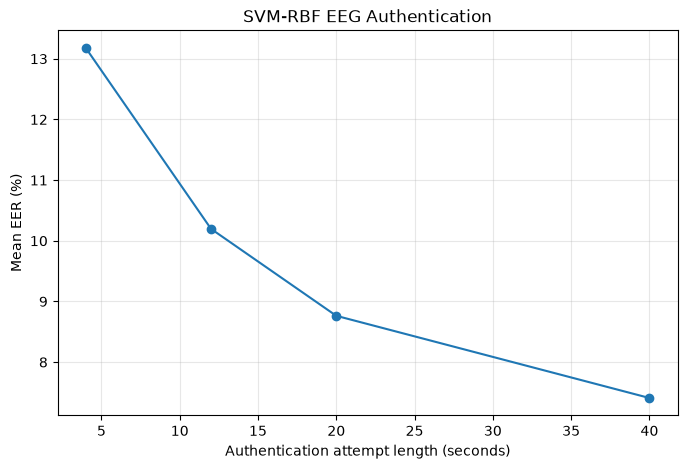

In [25]:
plt.figure(
    figsize=(8, 5)
)

plt.plot(
    summary["attempt_seconds"],
    summary["mean_EER_%"],
    marker="o"
)

plt.xlabel(
    "Authentication attempt length (seconds)"
)

plt.ylabel(
    "Mean EER (%)"
)

plt.title(
    "SVM-RBF EEG Authentication"
)

plt.grid(
    alpha=0.3
)

plt.show()

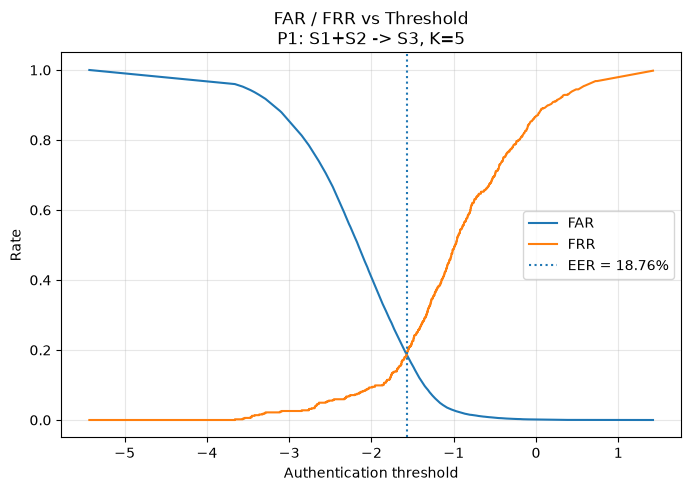

In [26]:
plot_key = (
    "P1: S1+S2 -> S3",
    5
)

r = result_objects[
    plot_key
]

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    r["thresholds"],
    r["fpr"],
    label="FAR"
)

plt.plot(
    r["thresholds"],
    1 - r["tpr"],
    label="FRR"
)

plt.axvline(
    r["threshold"],
    linestyle=":",
    label=f"EER = {r['EER']*100:.2f}%"
)

plt.xlabel(
    "Authentication threshold"
)

plt.ylabel(
    "Rate"
)

plt.title(
    "FAR / FRR vs Threshold\n"
    + plot_key[0]
    + f", K={plot_key[1]}"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

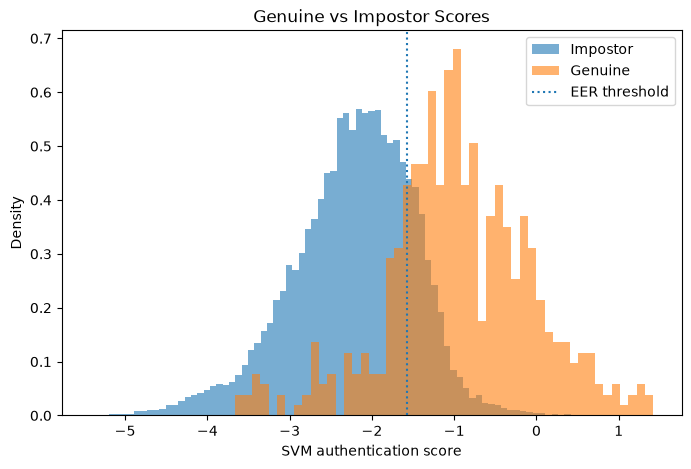

In [27]:
plt.figure(
    figsize=(8, 5)
)

plt.hist(
    r["impostor_scores"],
    bins=80,
    alpha=0.6,
    density=True,
    label="Impostor"
)

plt.hist(
    r["genuine_scores"],
    bins=50,
    alpha=0.6,
    density=True,
    label="Genuine"
)

plt.axvline(
    r["threshold"],
    linestyle=":",
    label="EER threshold"
)

plt.xlabel(
    "SVM authentication score"
)

plt.ylabel(
    "Density"
)

plt.title(
    "Genuine vs Impostor Scores"
)

plt.legend()

plt.show()

In [28]:
RESULTS_DIR = os.path.join(
    DATASET_ROOT,
    "results"
)

os.makedirs(
    RESULTS_DIR,
    exist_ok=True
)

results_df.to_csv(
    os.path.join(
        RESULTS_DIR,
        "svm_authentication_results.csv"
    ),
    index=False
)

summary.to_csv(
    os.path.join(
        RESULTS_DIR,
        "svm_authentication_summary.csv"
    ),
    index=False
)

print(
    "Results saved to:",
    RESULTS_DIR
)

Results saved to: C:\Users\Sanjeev\OneDrive\Desktop\Brain ID\EEG\ds004148\results


In [30]:
start_time = time.time()

# Full-session K
# 299 sec session / 4 sec window = 74 complete windows
FULL_SESSION_K = int(299 // WINDOW_SECONDS)

K_LIST = [1, 3, 5, 10, 20, 30, 40, 50, 60, 70]

all_results = []
result_objects = {}

for permutation in PERMUTATIONS:

    for K in K_LIST:

        result = run_permutation(
            permutation,
            K
        )

        result_objects[
            (permutation["name"], K)
        ] = result

        all_results.append({
            key: value
            for key, value in result.items()
            if not isinstance(value, np.ndarray)
        })

        print(
            f"{permutation['name']} | "
            f"K={K} | "
            f"Duration={K * WINDOW_SECONDS}s | "
            f"EER={result['EER']*100:.2f}% | "
            f"AUC={result['ROC_AUC']:.4f}"
        )

results_df = pd.DataFrame(all_results)

print("\nFULL SESSION K:", FULL_SESSION_K)
print("FINAL RESULT COUNT:", len(results_df))


P1: S1+S2 -> S3
Enrollment samples: 6100
Authentication samples: 2635
Features: 114 -> PCA: 83
P1: S1+S2 -> S3 | K=1 | Duration=4s | EER=23.72% | AUC=0.8354

P1: S1+S2 -> S3
Enrollment samples: 6100
Authentication samples: 2635
Features: 114 -> PCA: 83
P1: S1+S2 -> S3 | K=3 | Duration=12s | EER=20.46% | AUC=0.8708

P1: S1+S2 -> S3
Enrollment samples: 6100
Authentication samples: 2635
Features: 114 -> PCA: 83
P1: S1+S2 -> S3 | K=5 | Duration=20s | EER=18.76% | AUC=0.8802

P1: S1+S2 -> S3
Enrollment samples: 6100
Authentication samples: 2635
Features: 114 -> PCA: 83
P1: S1+S2 -> S3 | K=10 | Duration=40s | EER=17.04% | AUC=0.8924

P1: S1+S2 -> S3
Enrollment samples: 6100
Authentication samples: 2635
Features: 114 -> PCA: 83
P1: S1+S2 -> S3 | K=20 | Duration=80s | EER=17.42% | AUC=0.9037

P1: S1+S2 -> S3
Enrollment samples: 6100
Authentication samples: 2635
Features: 114 -> PCA: 83
P1: S1+S2 -> S3 | K=30 | Duration=120s | EER=15.71% | AUC=0.9162

P1: S1+S2 -> S3
Enrollment samples: 6100
A

Accuracy With 4 Sec Windwing 

In [33]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score

accuracy_results = []

print("\n" + "=" * 80)
print("RBF SVM CLASSIFICATION ACCURACY")
print("=" * 80)

for permutation in PERMUTATIONS:

    name = permutation["name"]

    print("\n" + "-" * 80)
    print(name)
    print("-" * 80)

    # ------------------------------------------
    # Get enrollment and authentication data
    # ------------------------------------------

    X_train, y_train = get_enrollment_data(
        permutation["enroll"]
    )

    X_test, y_test = get_test_data(
        permutation["test"]
    )

    # ------------------------------------------
    # Train RBF SVM
    # ------------------------------------------

    model, scaler, pca = train_svm(
        X_train,
        y_train
    )

    # ------------------------------------------
    # Transform authentication data
    # ------------------------------------------

    X_test_scaled = scaler.transform(
        X_test
    )

    X_test_pca = pca.transform(
        X_test_scaled
    )

    # ------------------------------------------
    # Predict subject
    # ------------------------------------------

    y_pred = model.predict(
        X_test_pca
    )

    # ------------------------------------------
    # Accuracy
    # ------------------------------------------

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    balanced_accuracy = balanced_accuracy_score(
        y_test,
        y_pred
    )

    accuracy_results.append({
        "Permutation": name,
        "Accuracy": accuracy,
        "Accuracy_%": accuracy * 100,
        "Balanced_Accuracy": balanced_accuracy,
        "Balanced_Accuracy_%": balanced_accuracy * 100,
        "Test_Samples": len(y_test)
    })

    print(
        f"Test samples       : {len(y_test)}"
    )

    print(
        f"Accuracy            : {accuracy * 100:.2f}%"
    )

    print(
        f"Balanced Accuracy   : "
        f"{balanced_accuracy * 100:.2f}%"
    )


# ------------------------------------------
# Final Accuracy Table
# ------------------------------------------

accuracy_df = pd.DataFrame(
    accuracy_results
)

print("\n" + "=" * 80)
print("FINAL RBF SVM ACCURACY")
print("=" * 80)

print(
    accuracy_df.to_string(
        index=False
    )
)


RBF SVM CLASSIFICATION ACCURACY

--------------------------------------------------------------------------------
P1: S1+S2 -> S3
--------------------------------------------------------------------------------
Features: 114 -> PCA: 83
Test samples       : 2635
Accuracy            : 26.03%
Balanced Accuracy   : 22.45%

--------------------------------------------------------------------------------
P2: S3+S2 -> S1
--------------------------------------------------------------------------------
Features: 114 -> PCA: 83
Test samples       : 3060
Accuracy            : 73.01%
Balanced Accuracy   : 69.34%

--------------------------------------------------------------------------------
P3: S1+S3 -> S2
--------------------------------------------------------------------------------
Features: 114 -> PCA: 83
Test samples       : 3040
Accuracy            : 69.44%
Balanced Accuracy   : 65.74%

FINAL RBF SVM ACCURACY
    Permutation  Accuracy  Accuracy_%  Balanced_Accuracy  Balanced_Accuracy_%  

Aggregate Accuracy 

In [35]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score
import numpy as np
import pandas as pd

aggregate_accuracy_results = []

print("\n" + "=" * 100)
print("AGGREGATED RBF SVM CLASSIFICATION ACCURACY")
print("=" * 100)

for permutation in PERMUTATIONS:

    name = permutation["name"]

    print("\n" + "-" * 100)
    print(name)
    print("-" * 100)

    # --------------------------------------------------
    # Load enrollment and authentication data
    # --------------------------------------------------

    X_train, y_train = get_enrollment_data(
        permutation["enroll"]
    )

    X_test, y_test = get_test_data(
        permutation["test"]
    )

    # --------------------------------------------------
    # Train RBF SVM
    # --------------------------------------------------

    model, scaler, pca = train_svm(
        X_train,
        y_train
    )

    # --------------------------------------------------
    # Transform authentication data
    # --------------------------------------------------

    X_test_scaled = scaler.transform(
        X_test
    )

    X_test_pca = pca.transform(
        X_test_scaled
    )

    # --------------------------------------------------
    # SVM decision scores for every 4-second window
    # --------------------------------------------------

    decision_scores = model.decision_function(
        X_test_pca
    )

    valid_subject_ids = np.unique(y_train)

    # ==================================================
    # Calculate accuracy for every K
    # ==================================================

    for K in K_LIST:

        y_true_aggregated = []
        y_pred_aggregated = []

        # Process every subject separately
        for subject_id in valid_subject_ids:

            subject_mask = (
                y_test == subject_id
            )

            subject_scores = (
                decision_scores[subject_mask]
            )

            if len(subject_scores) < K:
                continue

            # Number of complete K-window attempts
            n_attempts = (
                len(subject_scores) // K
            )

            for a in range(n_attempts):

                start = a * K
                end = start + K

                # ------------------------------------------
                # Aggregate K consecutive windows
                # ------------------------------------------

                attempt_scores = (
                    subject_scores[start:end]
                    .mean(axis=0)
                )

                # ------------------------------------------
                # Predicted subject
                # ------------------------------------------

                predicted_index = np.argmax(
                    attempt_scores
                )

                predicted_subject = (
                    model.classes_[predicted_index]
                )

                # ------------------------------------------
                # Store true/predicted subject
                # ------------------------------------------

                y_true_aggregated.append(
                    subject_id
                )

                y_pred_aggregated.append(
                    predicted_subject
                )

        # --------------------------------------------------
        # Convert to numpy arrays
        # --------------------------------------------------

        y_true_aggregated = np.asarray(
            y_true_aggregated
        )

        y_pred_aggregated = np.asarray(
            y_pred_aggregated
        )

        # --------------------------------------------------
        # Accuracy
        # --------------------------------------------------

        if len(y_true_aggregated) == 0:
            continue

        accuracy = accuracy_score(
            y_true_aggregated,
            y_pred_aggregated
        )

        balanced_accuracy = balanced_accuracy_score(
            y_true_aggregated,
            y_pred_aggregated
        )

        aggregate_accuracy_results.append({

            "Permutation": name,

            "K": K,

            "Duration_sec":
                K * WINDOW_SECONDS,

            "Attempts":
                len(y_true_aggregated),

            "Accuracy_%":
                accuracy * 100,

            "Balanced_Accuracy_%":
                balanced_accuracy * 100
        })

        print(
            f"K={K:<3} | "
            f"Duration={K * WINDOW_SECONDS:<3}s | "
            f"Attempts={len(y_true_aggregated):<4} | "
            f"Accuracy={accuracy*100:6.2f}% | "
            f"Balanced Accuracy={balanced_accuracy*100:6.2f}%"
        )


# ======================================================
# Final results table
# ======================================================

aggregate_accuracy_df = pd.DataFrame(
    aggregate_accuracy_results
)

aggregate_accuracy_df = (
    aggregate_accuracy_df
    .sort_values(
        ["Permutation", "K"]
    )
    .reset_index(drop=True)
)

print("\n" + "=" * 100)
print("FINAL AGGREGATED ACCURACY RESULTS")
print("=" * 100)

print(
    aggregate_accuracy_df.to_string(
        index=False
    )
)


AGGREGATED RBF SVM CLASSIFICATION ACCURACY

----------------------------------------------------------------------------------------------------
P1: S1+S2 -> S3
----------------------------------------------------------------------------------------------------
Features: 114 -> PCA: 83
K=1   | Duration=4  s | Attempts=2635 | Accuracy= 26.03% | Balanced Accuracy= 22.45%
K=3   | Duration=12 s | Attempts=859  | Accuracy= 32.83% | Balanced Accuracy= 30.91%
K=5   | Duration=20 s | Attempts=506  | Accuracy= 35.77% | Balanced Accuracy= 35.08%
K=10  | Duration=40 s | Attempts=241  | Accuracy= 39.83% | Balanced Accuracy= 38.29%
K=20  | Duration=80 s | Attempts=102  | Accuracy= 42.16% | Balanced Accuracy= 41.00%
K=30  | Duration=120s | Attempts=63   | Accuracy= 42.86% | Balanced Accuracy= 40.62%
K=40  | Duration=160s | Attempts=37   | Accuracy= 43.24% | Balanced Accuracy= 43.24%
K=50  | Duration=200s | Attempts=28   | Accuracy= 35.71% | Balanced Accuracy= 35.71%
K=60  | Duration=240s | Attempts